# Extracting temperature data from ERA5

In [1]:
import xarray as xr
import pandas as pd
from pathlib import Path

In [2]:
lonlat = pd.read_csv('../data/raw/locations_centroids.csv')

## Max temp

In [4]:
files = sorted(Path("../data/raw/chirts/chirts_max").glob("chirts_tmax_*.nc"))

ds_max = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [5]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(points.lon.values, dims="points")
lats = xr.DataArray(points.lat.values, dims="points")

tmax = ds_max["temp"].sel(
    longitude=lons,
    latitude=lats,
    method="nearest"
) 

In [6]:
tmax.to_dataframe().isnull().sum()

latitude        0
longitude       0
temp         4480
dtype: int64

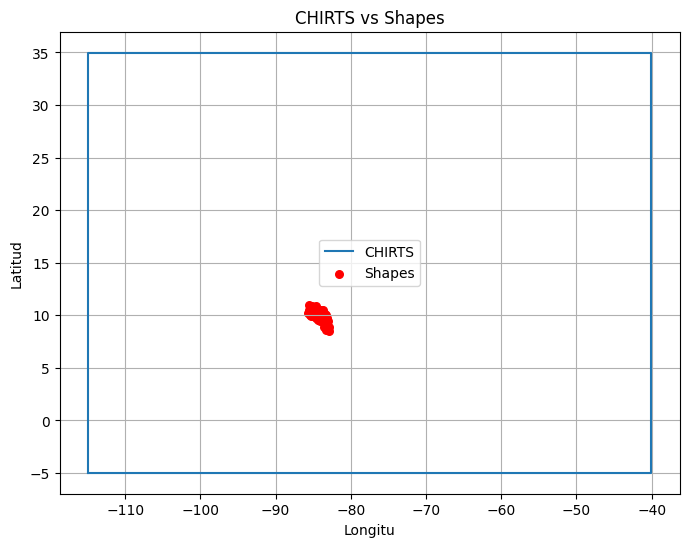

In [7]:
import matplotlib.pyplot as plt

lon_min = float(ds_max.longitude.min())
lon_max = float(ds_max.longitude.max())
lat_min = float(ds_max.latitude.min())
lat_max = float(ds_max.latitude.max())

plt.figure(figsize=(8, 6))

plt.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    label="CHIRTS",
)

# Plot your points
plt.scatter(points.lon, points.lat, c="red", s=30, label="Shapes")

plt.xlabel("Longitu")
plt.ylabel("Latitud")
plt.legend()
plt.title("CHIRTS vs Shapes")
plt.grid(True)
plt.show()


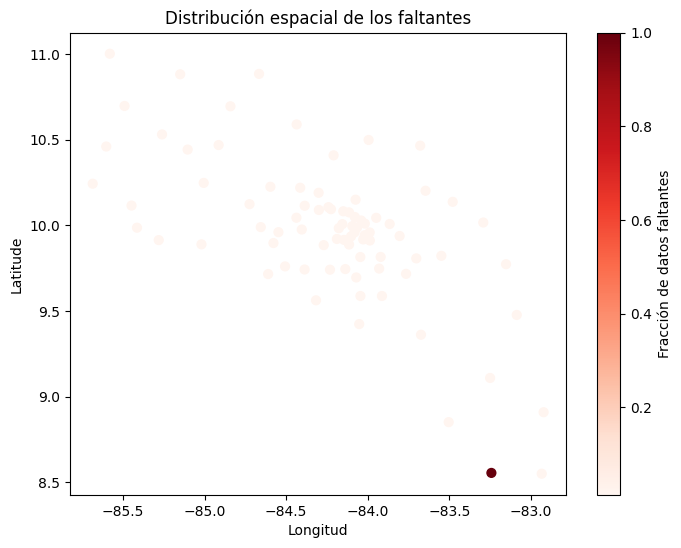

In [8]:
nan_fraction = tmax.isnull().mean("time")

plt.figure(figsize=(8, 6))
plt.scatter(points.lon, points.lat, c=nan_fraction, cmap="Reds", s=40)
plt.colorbar(label="Fracción de datos faltantes")
plt.xlabel("Longitud")
plt.ylabel("Latitude")
plt.title("Distribución espacial de los faltantes")
plt.show()


In [9]:
print("CHIRTS lon:", lon_min, lon_max)
print("CHIRTS lat:", lat_min, lat_max)

print("Points lon:", points.lon.min(), points.lon.max())
print("Points lat:", points.lat.min(), points.lat.max())


CHIRTS lon: -114.97500610351562 -40.02500915527344
CHIRTS lat: -4.975002288818359 34.974998474121094
Points lon: -85.68528480031924 -82.92271358809585
Points lat: 8.549269231183368 11.001918707120607


In [10]:
tmax_csv = (
    tmax
    .to_dataframe()
    .reset_index()
    .assign(
        lon=lambda df: points.loc[df["points"], "lon"].values,
        lat=lambda df: points.loc[df["points"], "lat"].values,
        canton=lambda df: points.loc[df["points"], "canton"].values
    )
    .drop(columns="points")
)

In [11]:
tmax_csv.head()

,time,latitude,longitude,temp,lon,lat,canton
0,2020-01-01,10.074997,-84.225006,26.218884,-84.225669,10.094073,Alajuela
1,2020-01-01,9.974998,-84.425003,27.761099,-84.404370,9.975320,Atenas
2,2020-01-01,10.074997,-84.275002,26.943682,-84.299504,10.089460,Grecia
3,2020-01-01,10.674995,-84.825005,32.480839,-84.841434,10.694885,Guatuso
4,2020-01-01,10.875000,-84.675003,32.247498,-84.666104,10.884147,Los Chiles


In [12]:
tmax_csv.to_csv('../data/raw/chirts/chirts_max/chirts_max.csv', index=False)

## Min temp

In [15]:
lonlat = pd.read_csv('../data/raw/locations.csv')

In [16]:
files = sorted(Path("../data/raw/chirts/chirts_min").glob("chirts_tmin_*.nc"))

ds_min = xr.open_mfdataset(
    files,
    engine="netcdf4",
    combine="by_coords",
    parallel=False
)

In [17]:
points = lonlat.reset_index(drop=True)

lons = xr.DataArray(points.lon.values, dims="points")
lats = xr.DataArray(points.lat.values, dims="points")

tmin = ds_min["temp"].interp(
    longitude=("points", points.lon.values),
    latitude=("points", points.lat.values),
    method="nearest"
)

In [18]:
tmin_csv = (
    tmax
    .to_dataframe()
    .reset_index()
    .assign(
        lon=lambda df: points.loc[df["points"], "lon"].values,
        lat=lambda df: points.loc[df["points"], "lat"].values,
        canton=lambda df: points.loc[df["points"], "canton"].values
    )
    .drop(columns="points")
)

In [20]:
tmin_csv.head()

,time,latitude,longitude,temp,lon,lat,canton
0,2020-01-01,8.375000,-83.325005,33.281307,-83.301849,8.39857,Golfito
1,2020-01-01,8.375000,-83.125008,32.920010,-83.101849,8.39857,Golfito
2,2020-01-01,8.375000,-83.025002,31.516523,-83.001849,8.39857,Corredores
3,2020-01-01,8.474998,-83.625008,33.984913,-83.601849,8.49857,Golfito
4,2020-01-01,8.474998,-83.525002,31.408983,-83.501849,8.49857,Golfito


In [19]:
tmin_csv.to_csv('../data/raw/chirts/chirts_min/chirts_min.csv', index=False)